# GRASSY Training Evaluation - α=5.0 (150 epochs)

This notebook visualizes the latent space embeddings from GRASSY training with α=5.0 (high property prediction emphasis), trained for 150 epochs total (resumed from epoch 100).


In [1]:
# Run the visualization script
import subprocess
import os
from pathlib import Path

# Create output directory
outdir = 'figs/zinc12k_evaluation_a5_150epochs'
os.makedirs(outdir, exist_ok=True)

# Run visualization with all 13 properties (saved directly from training)
cmd = [
    'python', 'visualize_latent_embeddings.py',
    '--embedding', 'scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-12-29-07/ordered_embedding_ZINC12K_regress_nokld.npy',
    '--labels', 'scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-12-29-07/embedding_prop_lists_ZINC12K_regress_nokld.npy',
    '--outdir', outdir,
    '--no-show'
]

print("Running visualization script (α=5.0, 150 epochs) with all 13 properties...")
print(f"Command: {' '.join(cmd)}")
print()

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors/Warnings:")
    print(result.stderr)

if result.returncode == 0:
    print("\n✅ Visualization complete!")
    print(f"Figures saved to: {outdir}")
    
    fig_files = list(Path(outdir).glob('*.png'))
    if fig_files:
        print("\nGenerated figures:")
        for f in sorted(fig_files):
            print(f"  - {f.name}")
else:
    print(f"\n❌ Visualization failed with return code {result.returncode}")


Running visualization script (α=5.0, 150 epochs) with all 13 properties...
Command: python visualize_latent_embeddings.py --embedding scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-12-29-07/ordered_embedding_ZINC12K_regress_nokld.npy --labels scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-12-29-07/embedding_prop_lists_ZINC12K_regress_nokld.npy --outdir figs/zinc12k_evaluation_a5_150epochs --no-show

Loading embedding: scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-12-29-07/ordered_embedding_ZINC12K_regress_nokld.npy
Embedding shape: (11994, 25)
Loading labels: scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-12-29-07/embedding_prop_lists_ZINC12K_regress_nokld.npy
Labels shape: (11994, 13)
Computing PCA...
Explained variance ratio (PCA): [0.1883813  0.13613942]
Computing PHATE...
Calculating PHATE...
  Running PHATE on 11994 observations and 25 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 13.90 seco

Found 26 figure(s):

📊 qed (PCA)


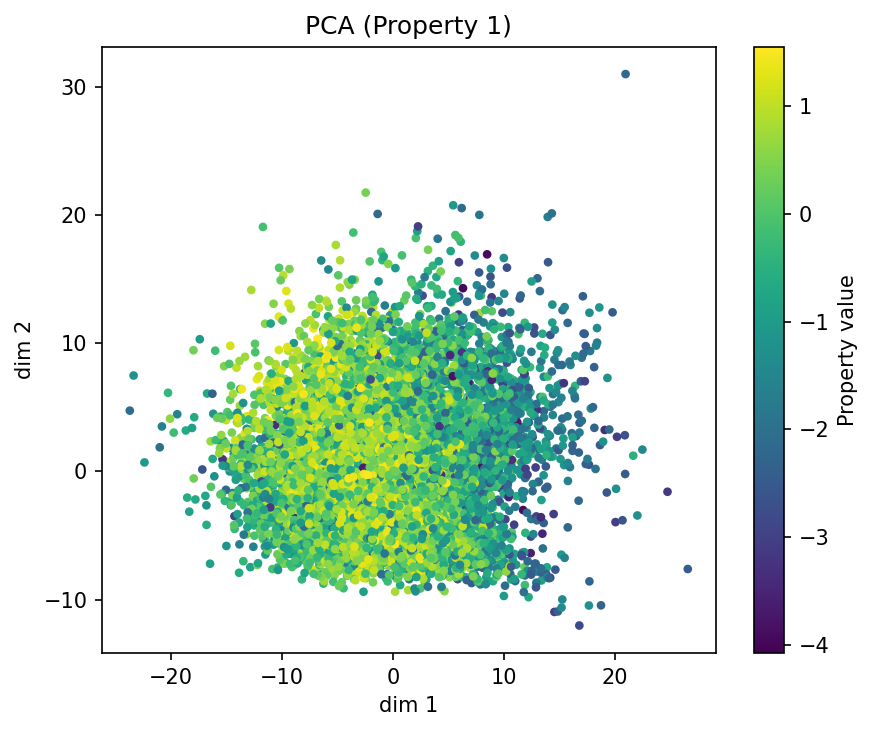


📊 qed (PHATE)


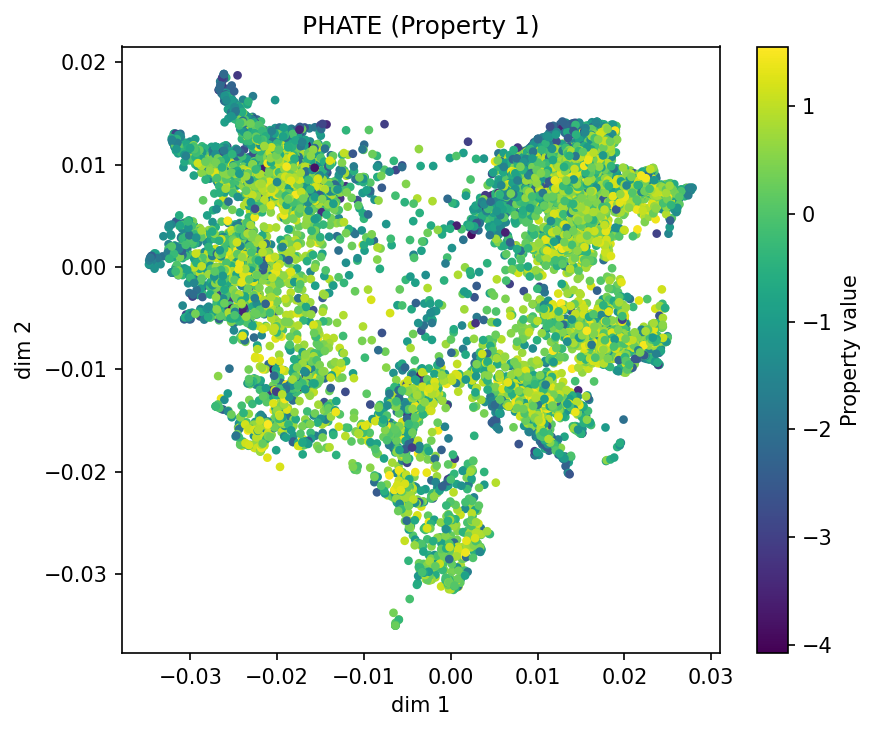


📊 HeavyAtomMolWt (PCA)


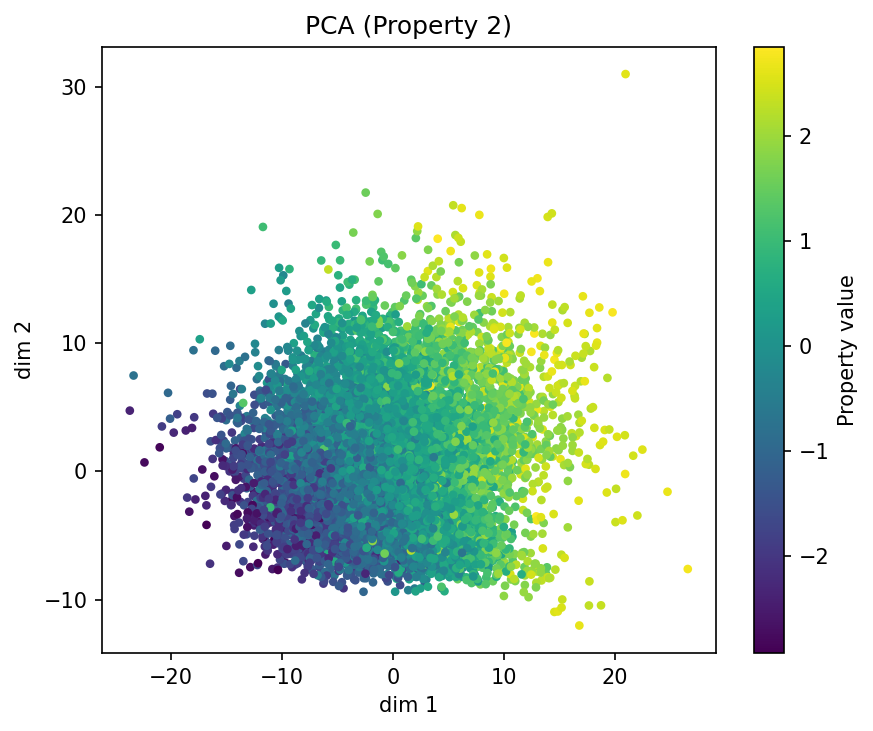


📊 HeavyAtomMolWt (PHATE)


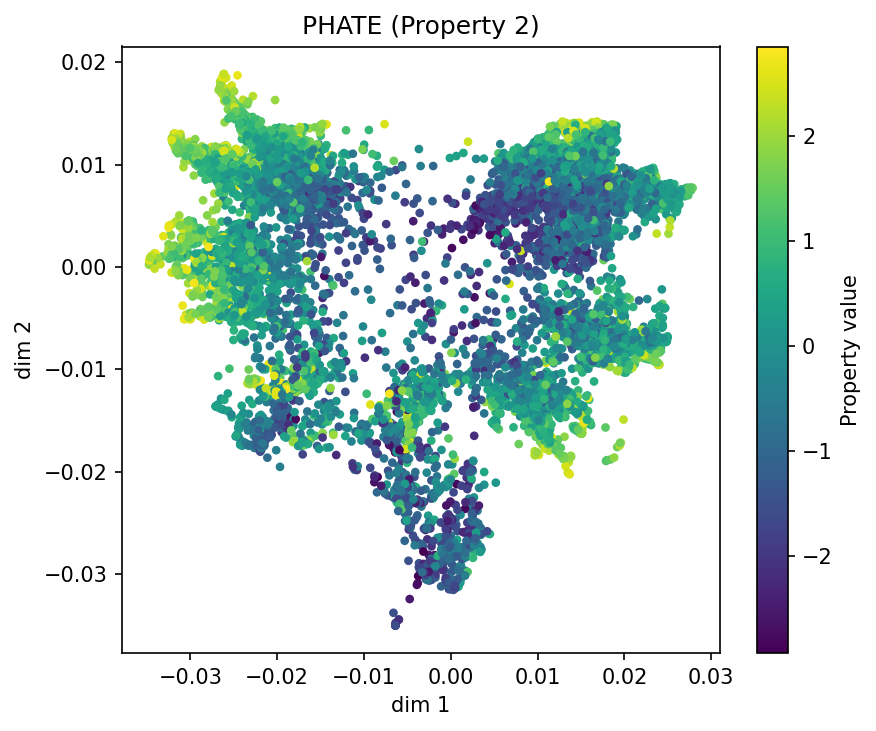


📊 MolWt (PCA)


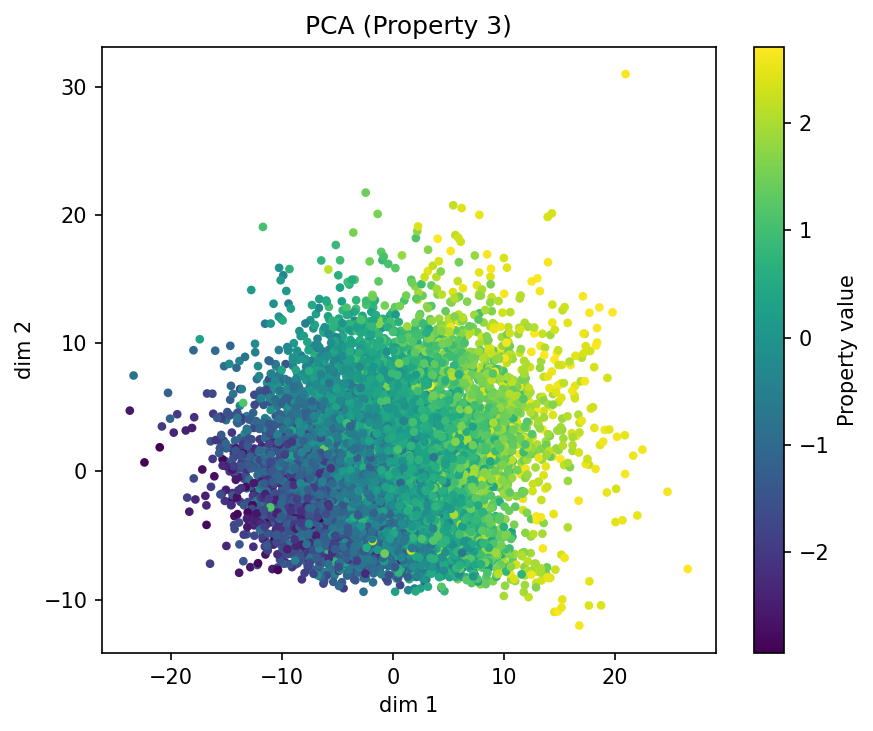


📊 MolWt (PHATE)


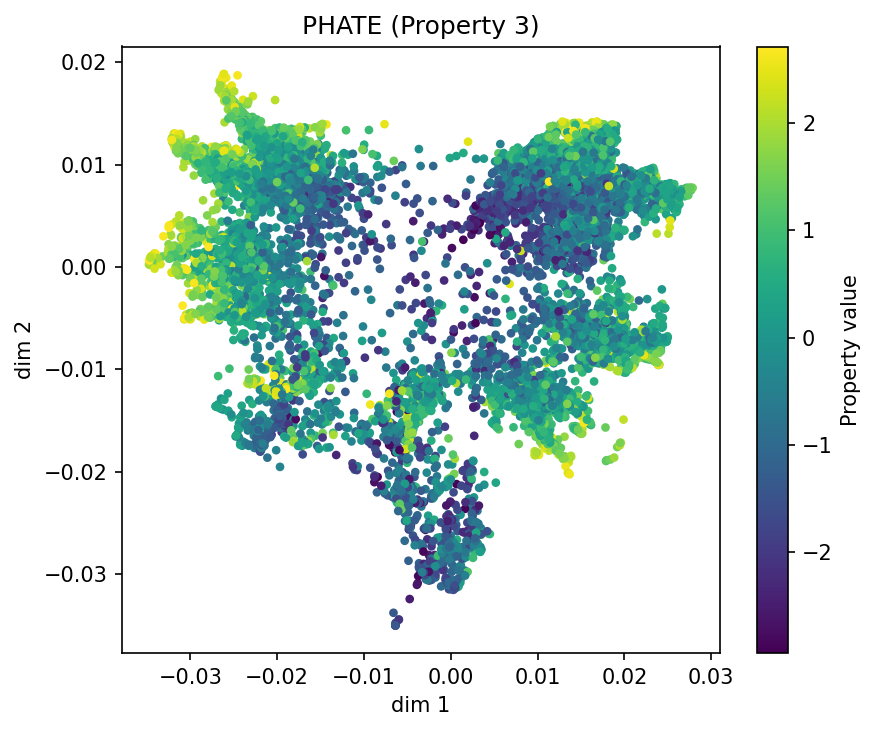


📊 BalabanJ (PCA)


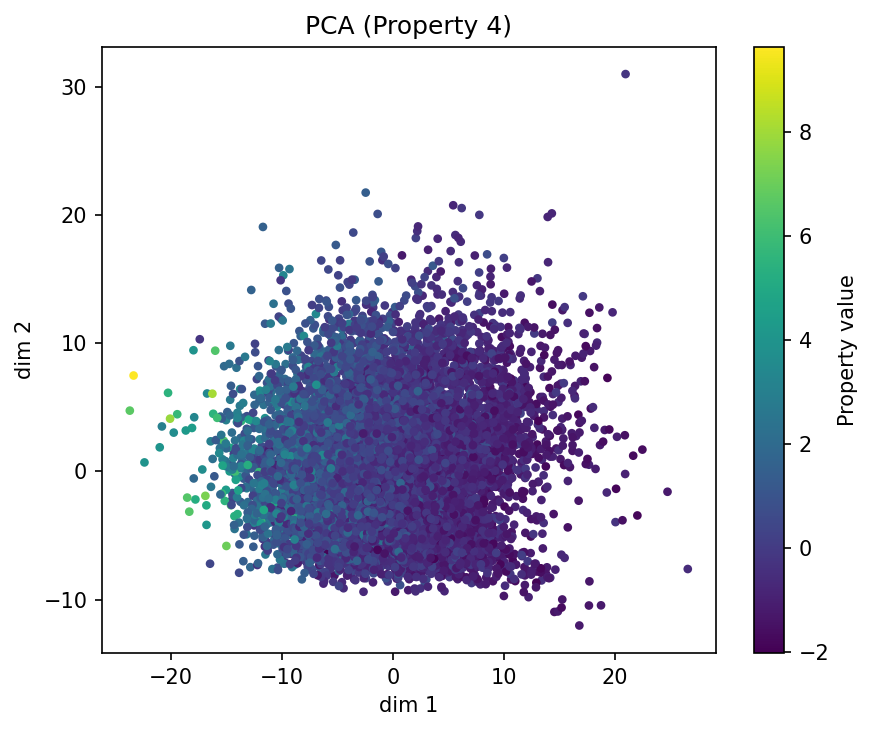


📊 BalabanJ (PHATE)


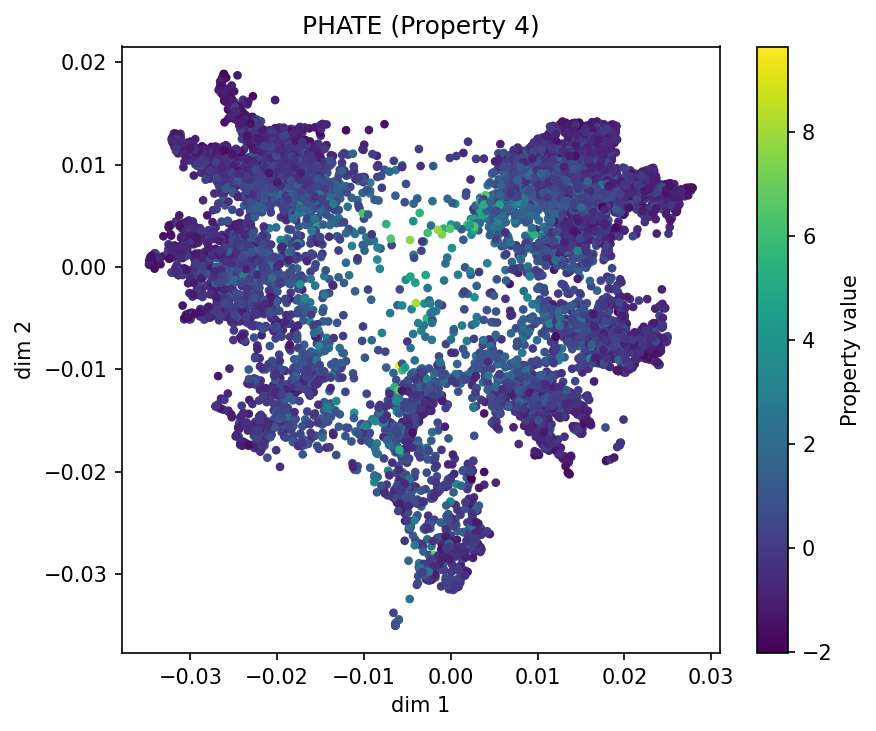


📊 BertzCT (PCA)


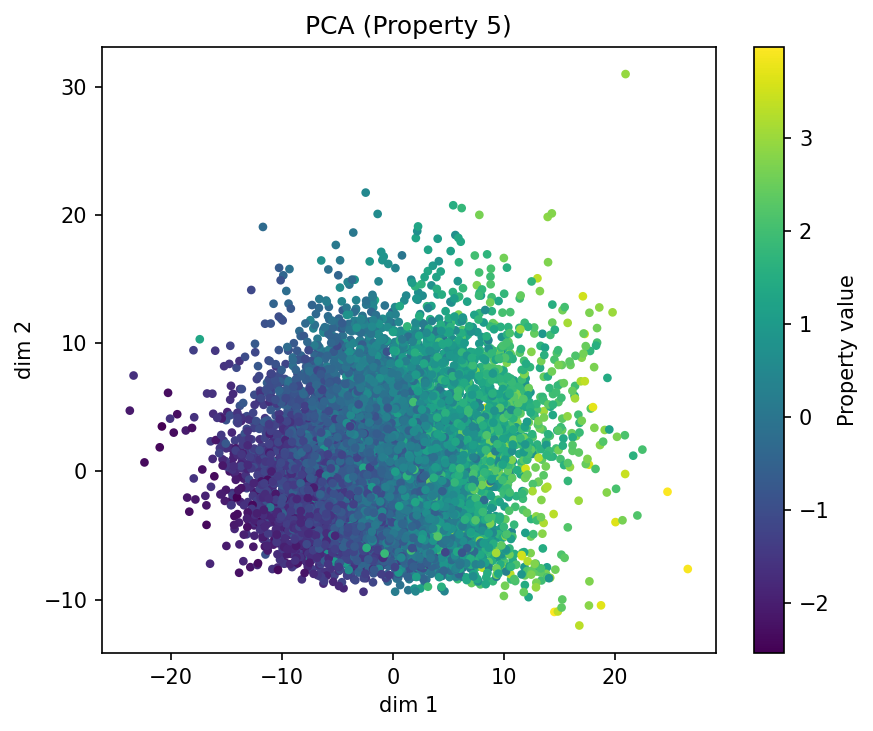


📊 BertzCT (PHATE)


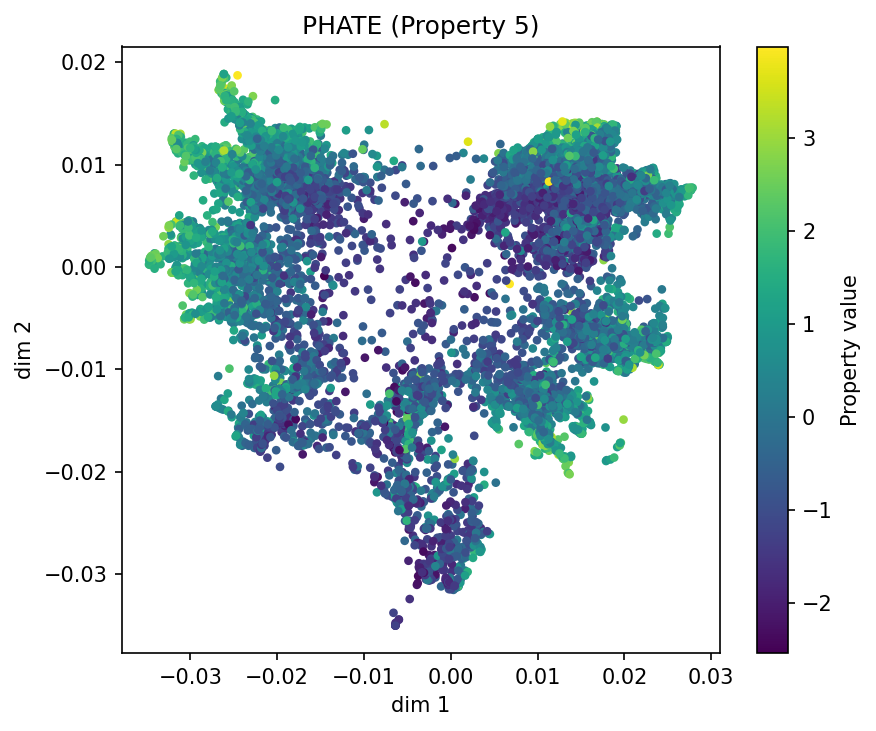


📊 Ipc (PCA)


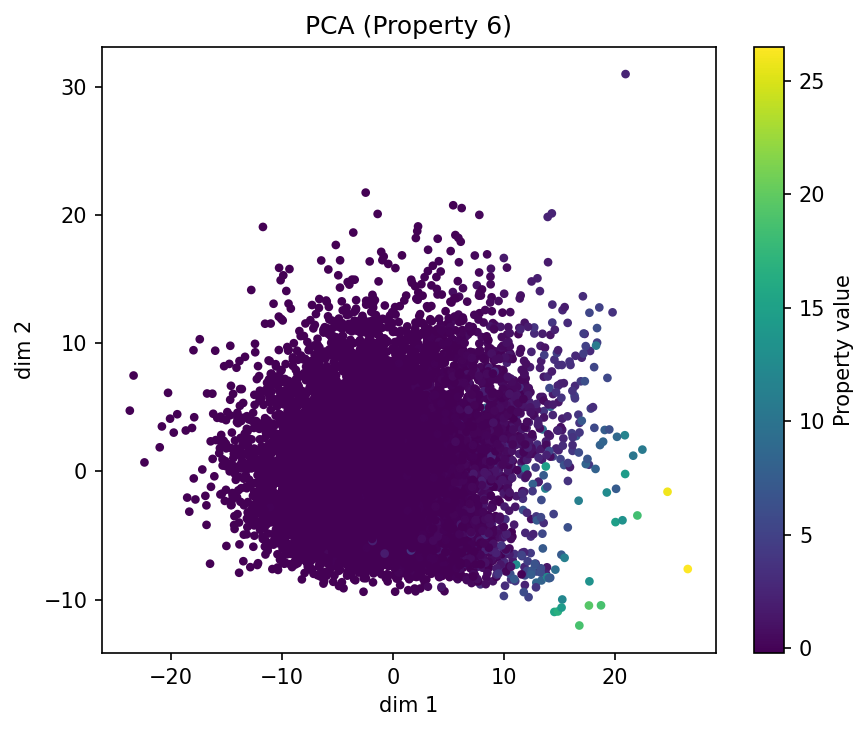


📊 Ipc (PHATE)


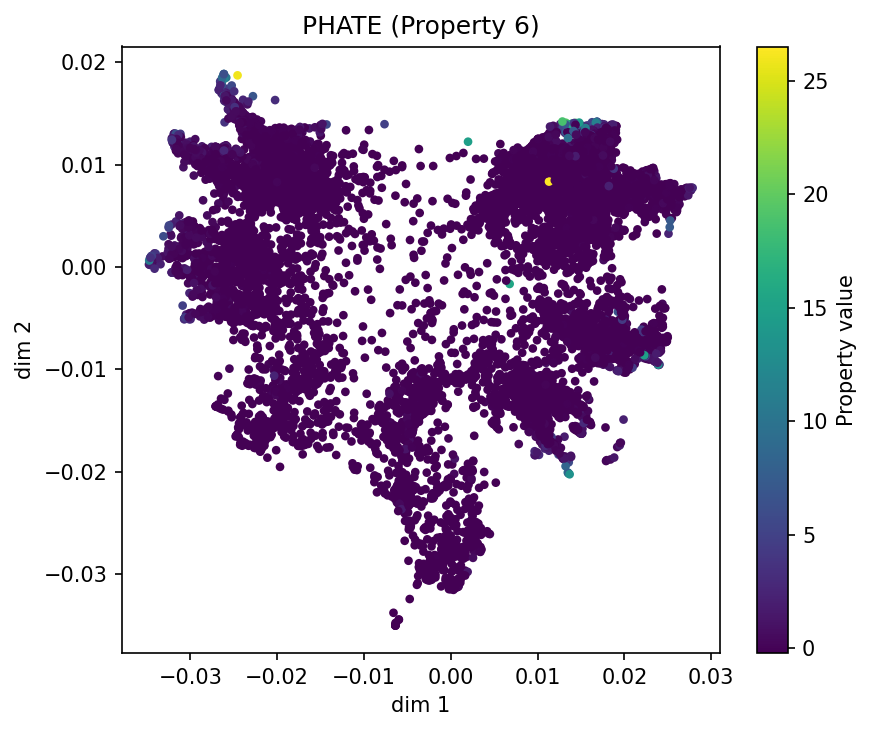


📊 TPSA (PCA)


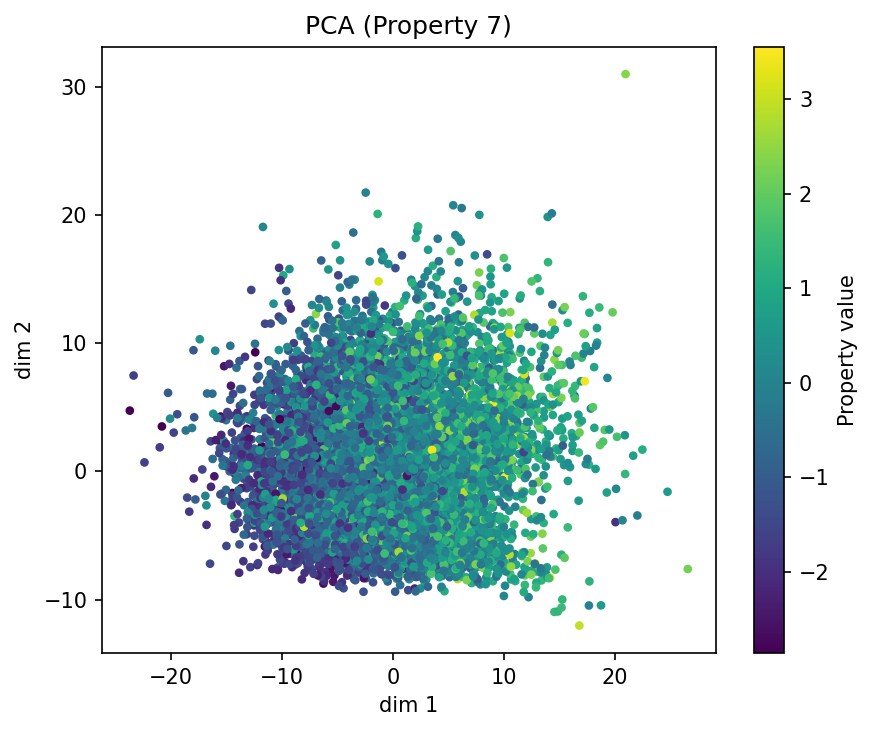


📊 TPSA (PHATE)


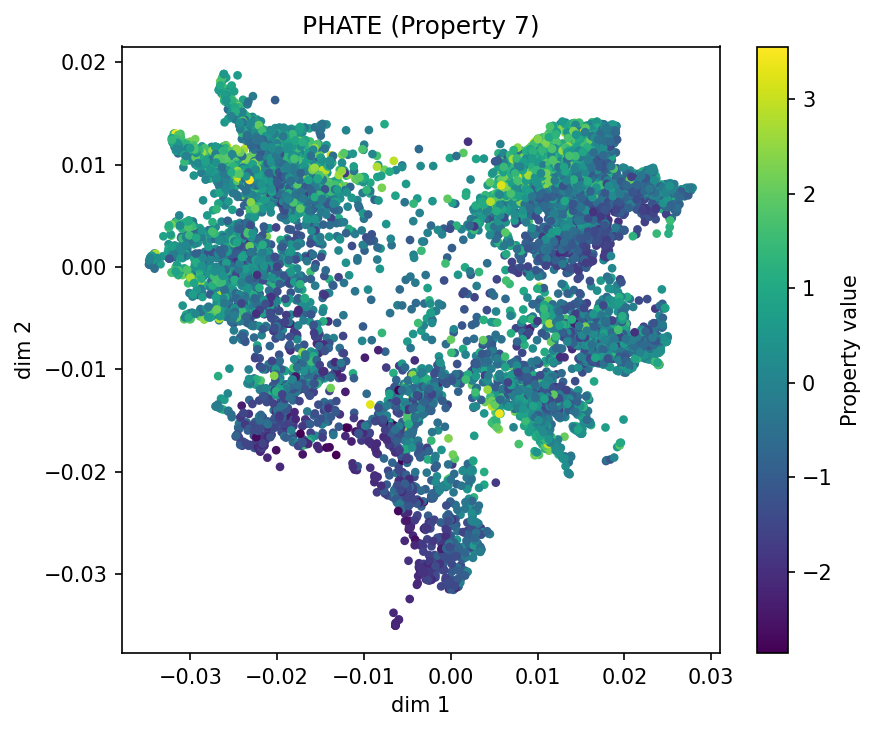


📊 NumHAcceptors (PCA)


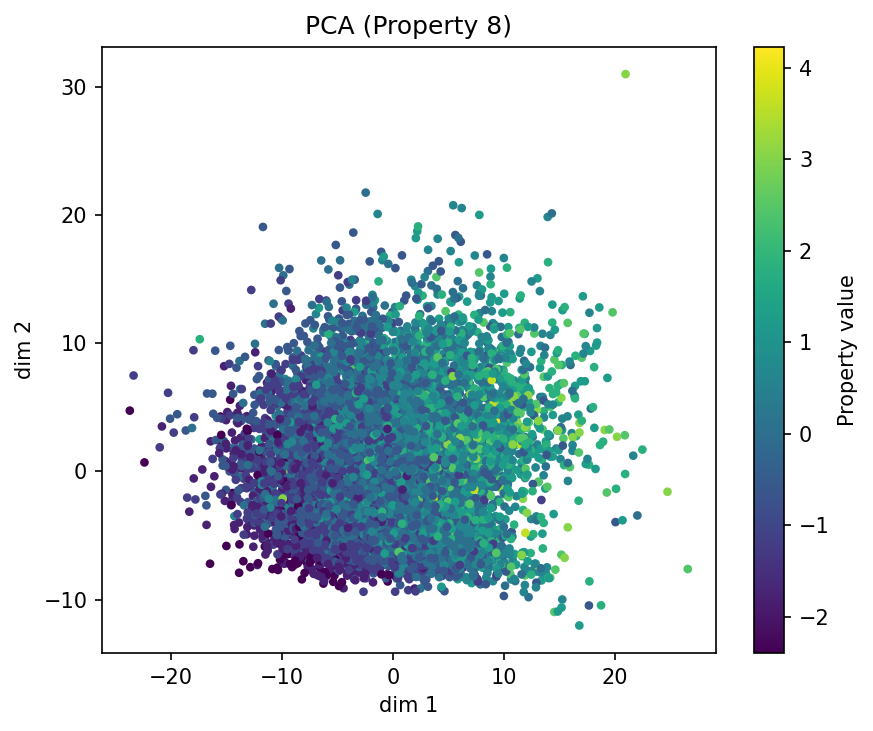


📊 NumHAcceptors (PHATE)


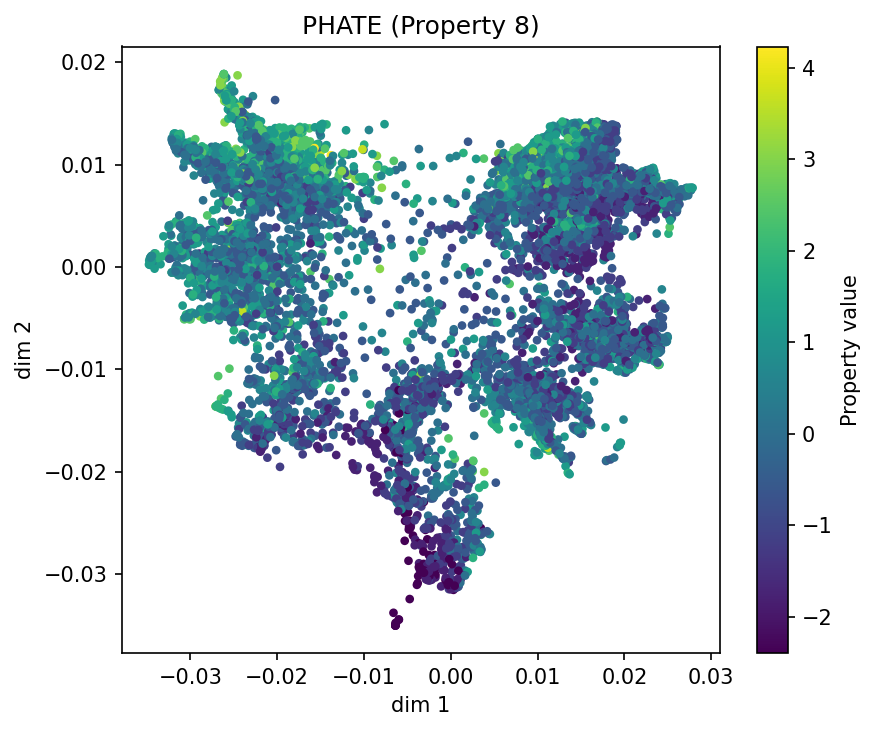


📊 NumHDonors (PCA)


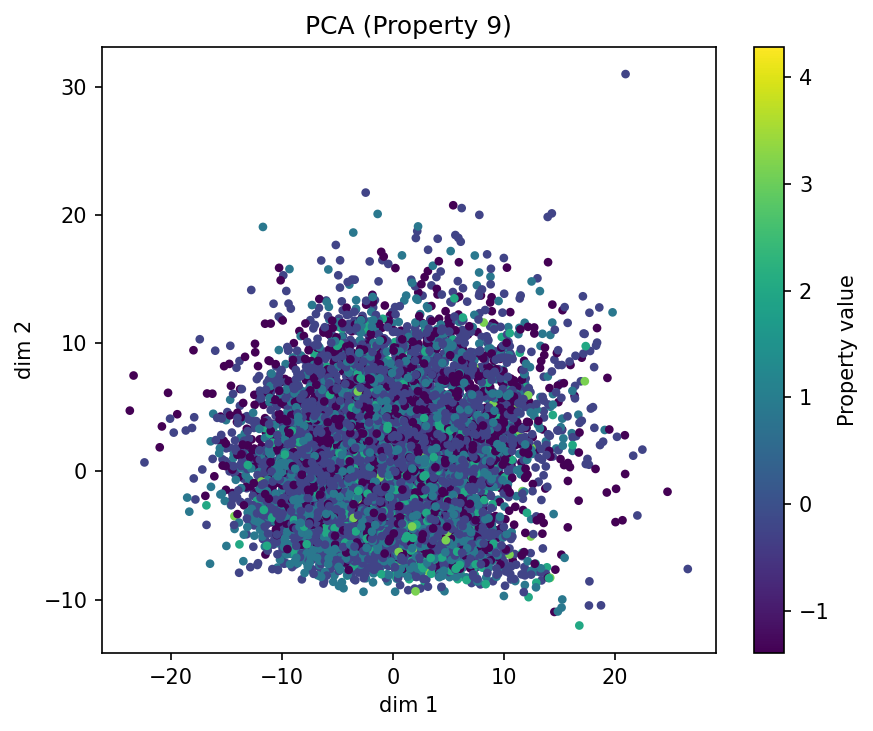


📊 NumHDonors (PHATE)


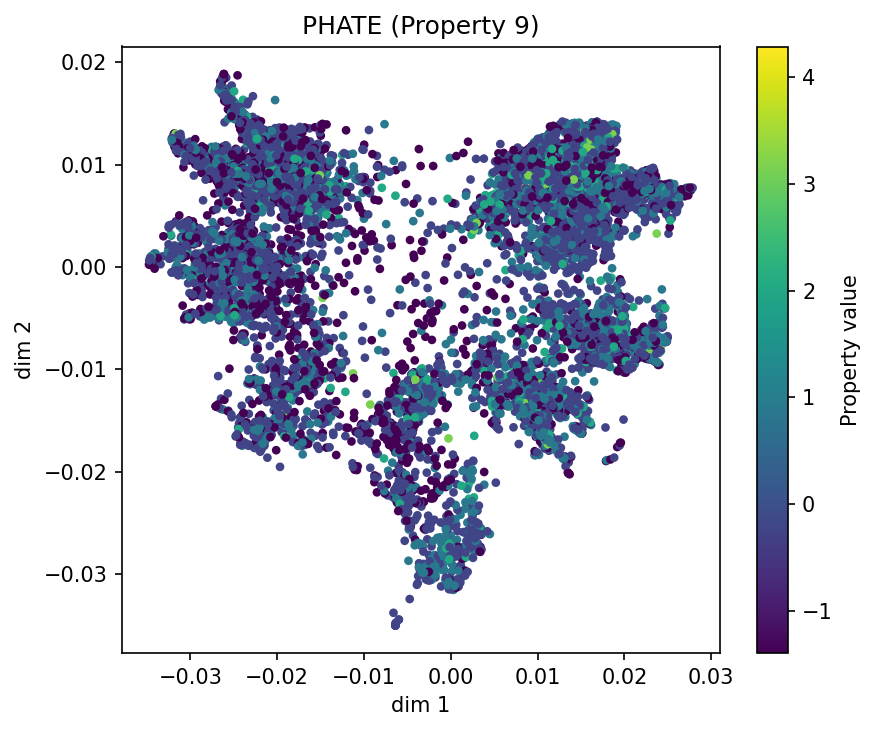


📊 RingCount (PCA)


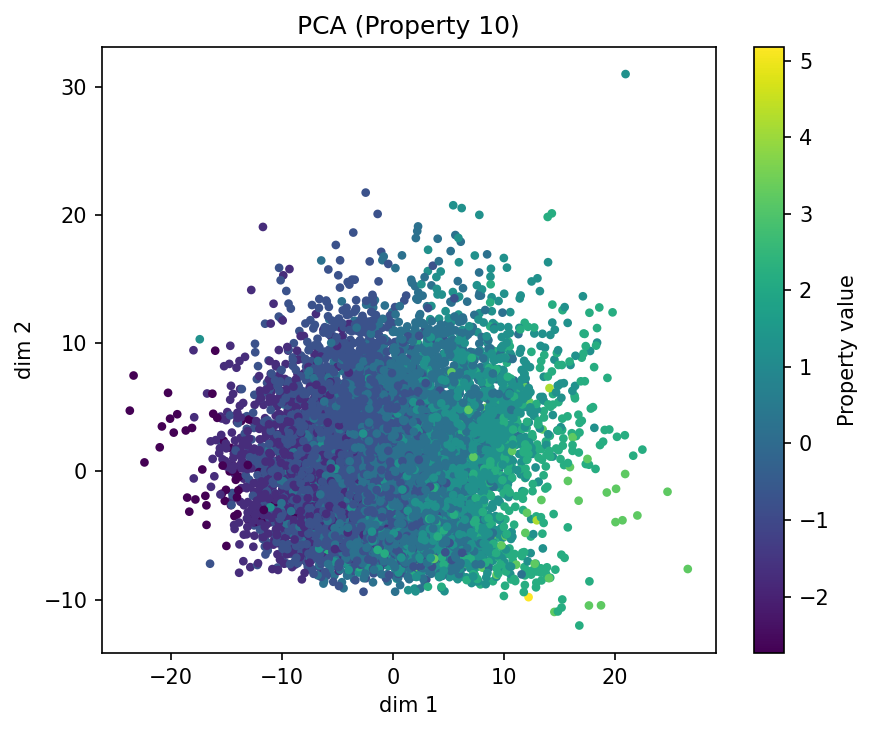


📊 RingCount (PHATE)


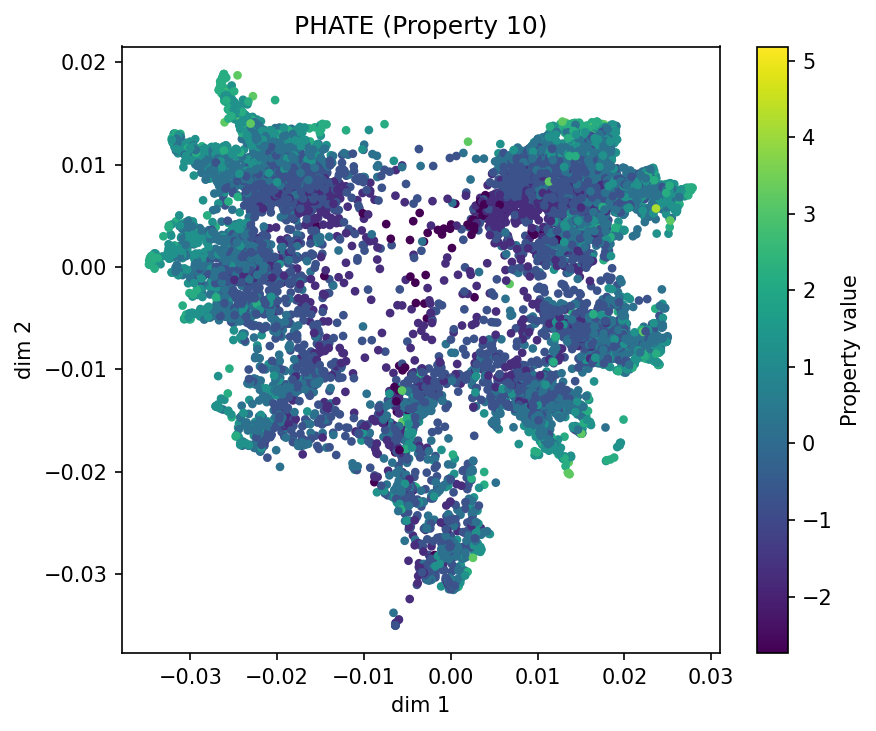


📊 MolLogP (PCA)


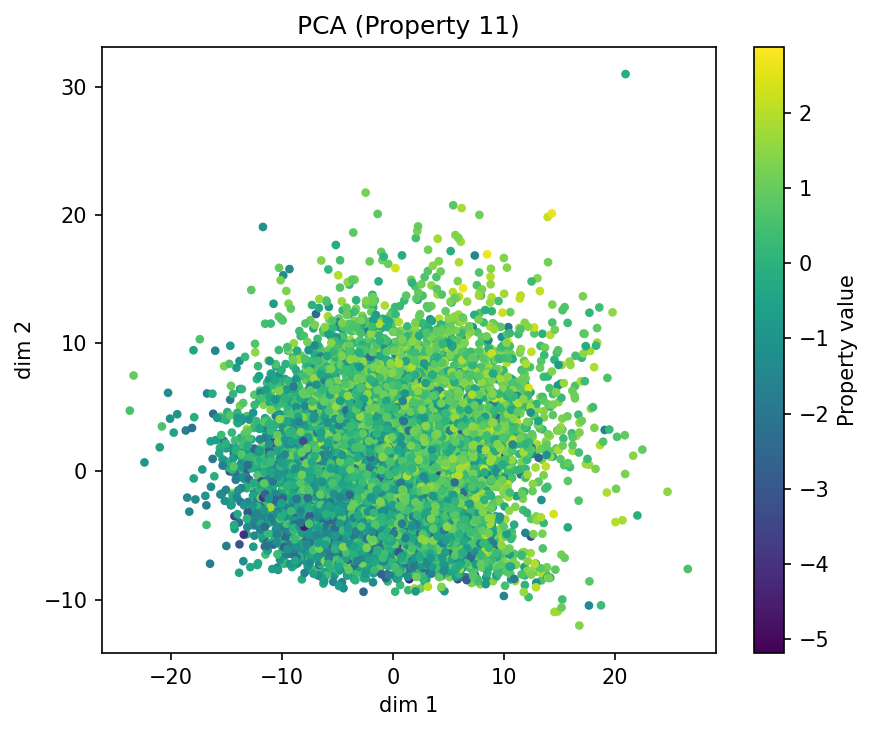


📊 MolLogP (PHATE)


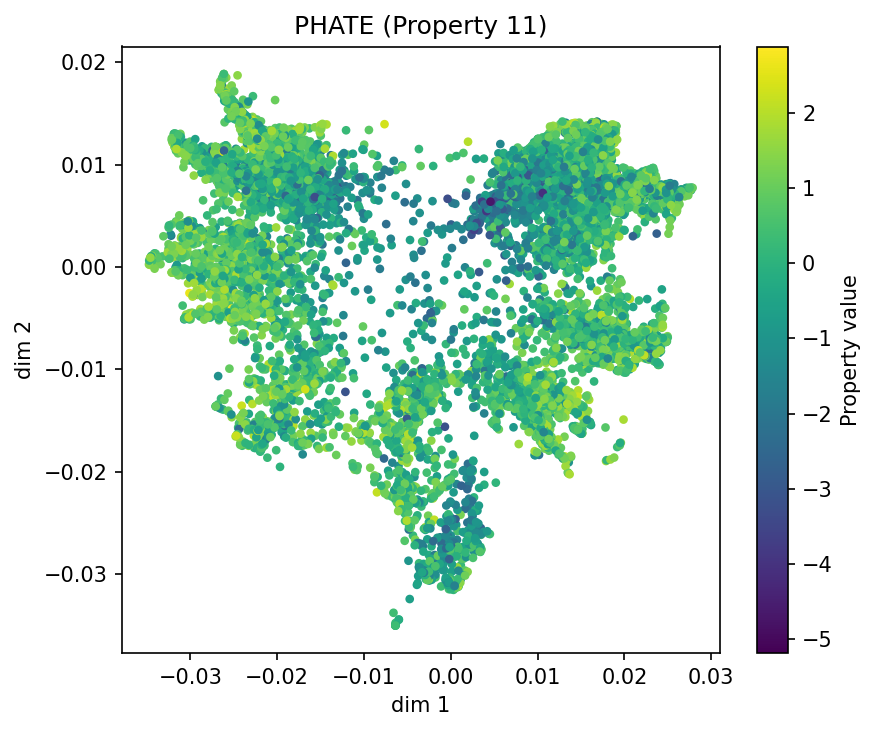


📊 SAscore (PCA)


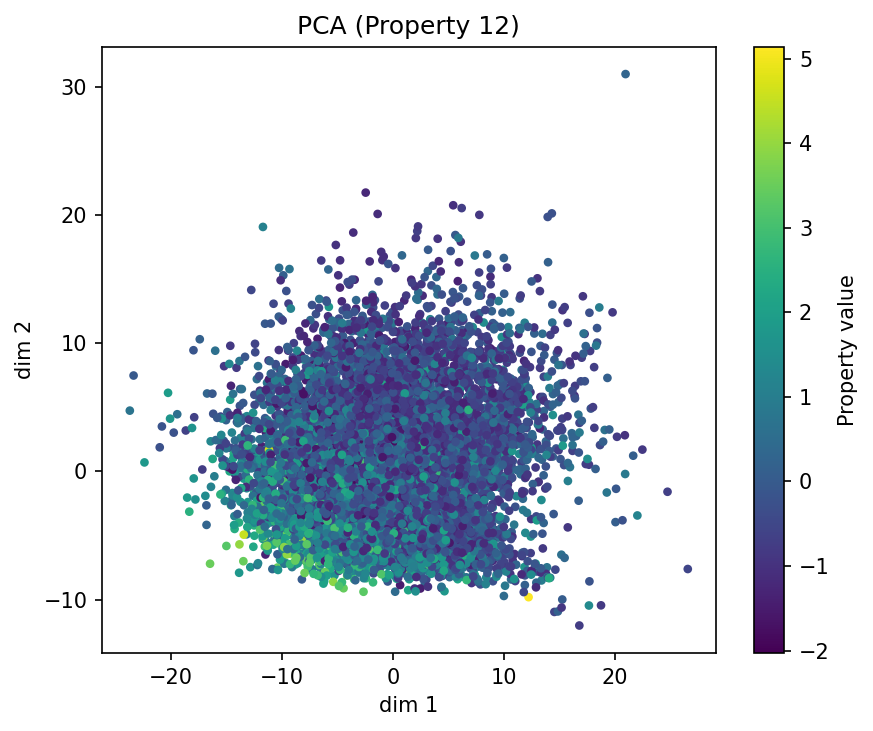


📊 SAscore (PHATE)


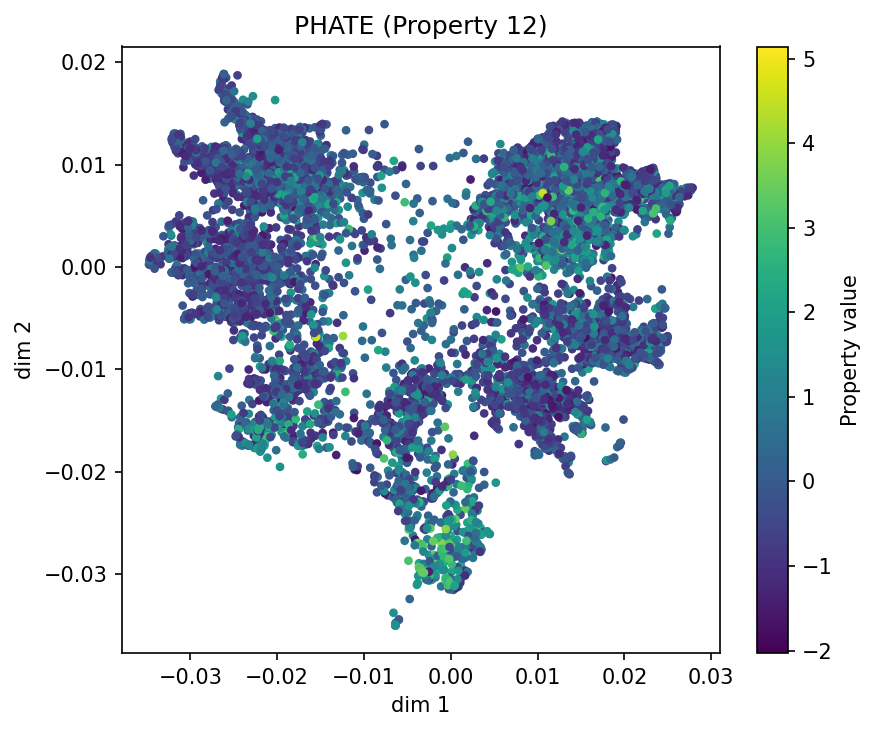


📊 FSP3 (PCA)


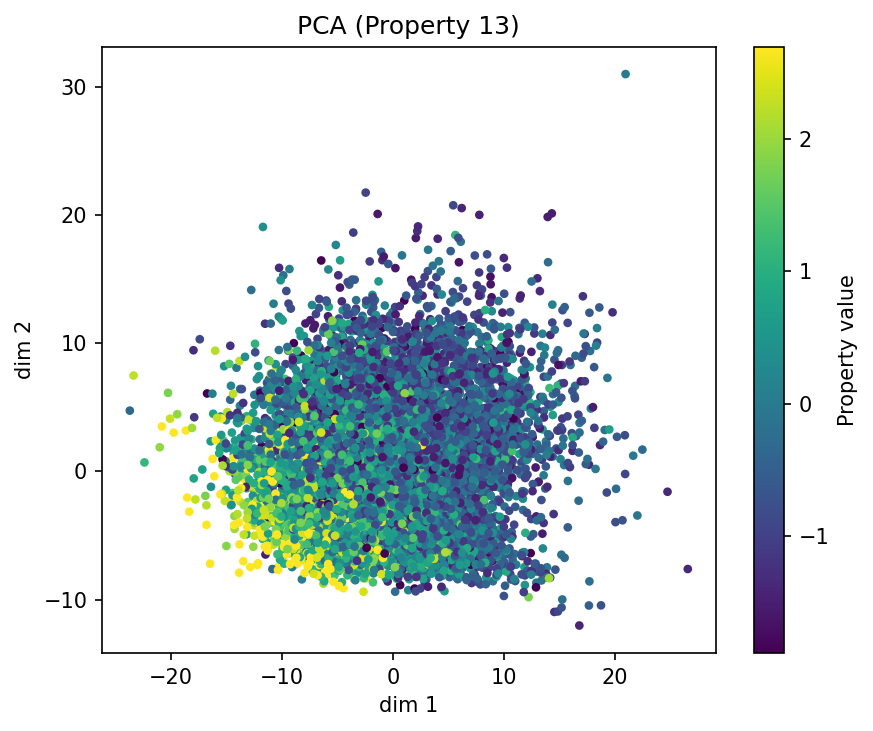


📊 FSP3 (PHATE)


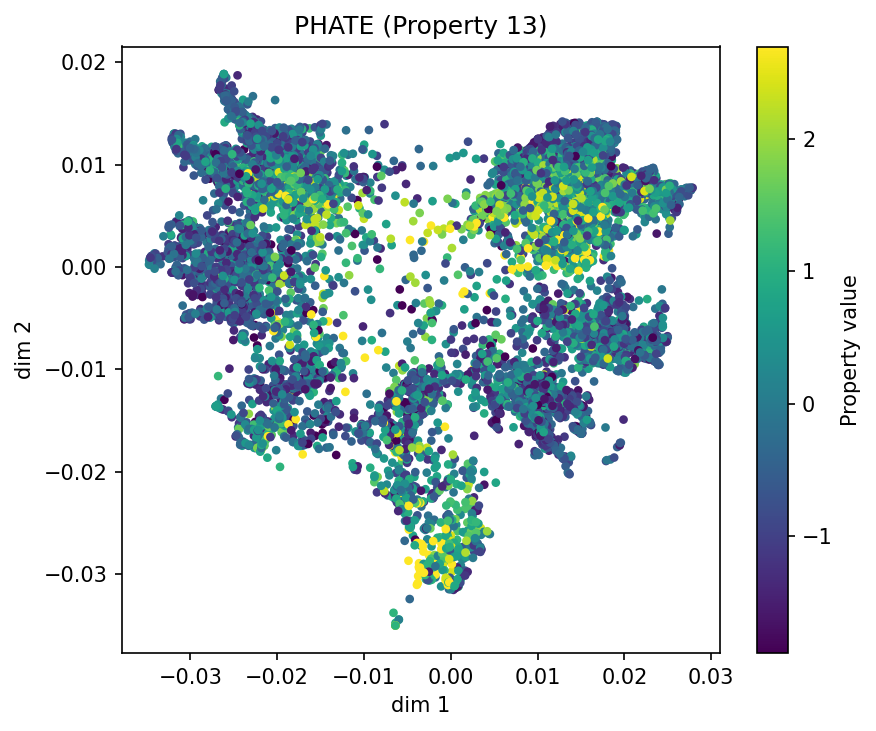

In [3]:
# Display the generated figures with property names
from IPython.display import Image, display
import glob

# Property names in order (from datasets/load_ZINC_tranche.py)
property_names = [
    'qed', 'HeavyAtomMolWt', 'MolWt', 'BalabanJ', 'BertzCT', 'Ipc', 
    'TPSA', 'NumHAcceptors', 'NumHDonors', 'RingCount', 'MolLogP', 
    'SAscore', 'FSP3'
]

fig_files = sorted(glob.glob(f'{outdir}/*.png'))
if fig_files:
    print(f"Found {len(fig_files)} figure(s):\n")
    
    # Group by property
    for prop_idx, prop_name in enumerate(property_names):
        prop_num = prop_idx + 1
        pca_file = f'{outdir}/latent_pca_prop{prop_num}.png'
        phate_file = f'{outdir}/latent_phate_prop{prop_num}.png'
        
        if os.path.exists(pca_file):
            print(f"📊 {prop_name} (PCA)")
            display(Image(pca_file))
            print()
        
        if os.path.exists(phate_file):
            print(f"📊 {prop_name} (PHATE)")
            display(Image(phate_file))
            print()
else:
    print(f"No figures found in {outdir}")